---
## 0. Config — shared knobs for all models

In [ ]:
# ── PATHS (edit to match your Colab/Drive) ──────────────────────────
VERA_PATH          = 'VERAARAB_dataset.xlsx'
ARAFACTS_PATH      = 'AraFacts.csv'
SAHEEH_EARLY_PATH  = 'saheeh_temporal_early.csv'    # from the temporal EDA notebook
SAHEEH_LATE_PATH   = 'saheeh_temporal_late.csv'     # HELD-OUT TEST — never trained on
BUCKET_B_PATH      = 'Bucket_B_Truth_CLEAN_FINAL.csv'   # all-real MSA corpus
# NOTE: MANUAL_CLAIMS_PATH intentionally absent — the manual set is removed from this experiment.

# ── DATA-MIXING KNOBS (unchanged from the original notebook) ────────
SEED                 = 42
VERA_CAP             = 7000
AF_FAKE_KEEP         = 2000
AF_FAKE_REAL_RATIO   = None
NEW_REAL_SUPERVISED  = 1000
EGY_FRACTION         = 0.60
MAX_PER_SOURCE       = 80
FP_STRESS_N          = 200    # reserved real-only slice; kept ONLY so the train pool matches the
                              # original. It is NOT evaluated anywhere in this comparison.

# ── SHORTCUT-PATTERN FIX (unchanged; part of the shared, model-agnostic preprocessing) ──
SHORTCUT_PATTERNS    = ['انتشر','تداول','هل ','أعلنت','زعم','يزعم','زاعم','يدّعي','ادعاء','مزاعم']
CONTENT_STRIP_FRAC   = 0.5

# ── MODELS UNDER COMPARISON ─────────────────────────────────────────
MARBERT_NAME = 'UBC-NLP/MARBERTv2'              # proposed model
ARABERT_NAME = 'aubmindlab/bert-base-arabertv2' # independent transformer baseline (MSA-pretrained)

# ── SHARED TRANSFORMER TRAINING SETTINGS (identical for AraBERT & MARBERTv2) ──
MAX_LENGTH   = 256
FT_EPOCHS    = 3
BATCH_TRAIN  = 16
BATCH_EVAL   = 32
LR           = 2e-5
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.1

# ── EXPERIMENT FLAGS ────────────────────────────────────────────────
USE_AUGMENTATION = True   # shortcut-pattern rebalancing on the TRAIN split only, shared by all 3 models
RUN_THRESHOLD_TUNING = True  # SECONDARY analysis only; headline numbers always use threshold 0.5
USE_TAPT = False          # OFF: TAPT is MARBERTv2-only and breaks the fair comparison (see intro)

print('✅ Config loaded — models:', MARBERT_NAME, '|', ARABERT_NAME)

✅ Config loaded — models: UBC-NLP/MARBERTv2 | aubmindlab/bert-base-arabertv2


---
## 1. Setup & imports

In [ ]:
!pip install -q transformers datasets accelerate scikit-learn pandas numpy tqdm openpyxl datasketch matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.9/99.9 kB 4.4 MB/s eta 0:00:00


In [ ]:
import pandas as pd, numpy as np, torch, random, os, re, gc
import torch.nn as nn
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          AutoModelForMaskedLM, Trainer, TrainingArguments,
                          EarlyStoppingCallback, DataCollatorWithPadding,
                          DataCollatorForLanguageModeling)
from datasets import Dataset
import matplotlib.pyplot as plt

def set_seed(seed=SEED):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
set_seed()

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', device)
if device == 'cpu':
    print('⚠️  Runtime > Change runtime type > GPU before continuing (two transformer fine-tunes are slow on CPU)')
print('✅ Setup complete')

Device: cuda
✅ Setup complete


---
## 2. Unified preprocessing
**One** normalizer, applied to **every** text consumed by **every** model — this is the shared
preprocessing the fairness contract requires. It is intentionally light (URL strip + whitespace
collapse): heavy, model-specific preprocessing (e.g. AraBERT's optional Farasa segmentation) is
*not* applied, because that would give one model a different input pipeline and break the
unified-preprocessing rule. See the note in Section 16 on how to opt into AraBERT-native
preprocessing if you want the per-model-optimal (non-unified) variant instead.

In [ ]:
def clean_basic(t):
    """Shared, model-agnostic text normalizer used for ALL text in ALL models/splits."""
    if not isinstance(t, str):
        return ''
    t = re.sub(r'http\S+', ' ', t)          # strip URLs
    return re.sub(r'\s+', ' ', t).strip()     # collapse whitespace

def clean_fulltext(t):
    # content reliably follows the LAST 'واتساب' in Youm7/AlMasry exports (used for the MSA corpus)
    if not isinstance(t, str):
        return ''
    if 'واتساب' in t:
        tail = t.rsplit('واتساب', 1)[-1]
        if len(tail) > 120:
            t = tail
    return clean_basic(t)

print('✅ Preprocessing helpers ready')

✅ Preprocessing helpers ready


---
## 3. Load datasets (manual set removed)
Identical to the original notebook **except** the manual claims file is not loaded.

In [ ]:
vera         = pd.read_excel(VERA_PATH)
arafacts     = pd.read_csv(ARAFACTS_PATH, low_memory=False)
saheeh_early = pd.read_csv(SAHEEH_EARLY_PATH, low_memory=False)
saheeh_late  = pd.read_csv(SAHEEH_LATE_PATH,  low_memory=False)
bucket_b     = pd.read_csv(BUCKET_B_PATH)

vera['text']         = vera['text_arabic'].astype(str).apply(clean_basic)
vera['binary_label'] = vera['label'].astype(int)
vera = vera[vera['text'].str.len() > 0].drop_duplicates(subset=['text']).reset_index(drop=True)

for d in (saheeh_early, saheeh_late):
    assert {'text','binary_label'}.issubset(d.columns), 'Saheeh splits need text + binary_label'
# apply the SAME normalizer to the supervised target + the held-out test
saheeh_early['text'] = saheeh_early['text'].astype(str).apply(clean_basic)
saheeh_late['text']  = saheeh_late['text'].astype(str).apply(clean_basic)

print(f'VERA (dedup):         {len(vera)}')
print(f'AraFacts (raw):       {len(arafacts)}')
print(f'Saheeh EARLY (train): {len(saheeh_early)}')
print(f'Saheeh LATE  (TEST):  {len(saheeh_late)}   <- held out, zero-shot, same for all models')
print(f'Bucket_B real MSA:    {len(bucket_b)}')

VERA (dedup):         16587
AraFacts (raw):       6222
Saheeh EARLY (train): 1557
Saheeh LATE  (TEST):  668   <- held out, zero-shot, same for all models
Bucket_B real MSA:    1384


---
## 4. Clean & prepare the all-real MSA corpus
Unchanged from the original (`text` = cleaned summary→title; `text_tapt` = cleaned full_text;
all rows real = 0).

In [ ]:
EGYPTIAN_KEYS = ['Youm7','Dostor','AlMasry','Sada']
PANARAB_KEYS  = ['RT_','AlJazeera','CNN','BBC','France24']

def region_of(src):
    s = str(src)
    if any(k in s for k in EGYPTIAN_KEYS): return 'egyptian'
    if any(k in s for k in PANARAB_KEYS):  return 'pan_arab'
    return 'pan_arab'

bucket_b['region']    = bucket_b['source'].apply(region_of)
bucket_b['text']      = bucket_b['summary'].apply(clean_basic)
bucket_b.loc[bucket_b['text'].str.len() < 10, 'text'] = bucket_b['title'].apply(clean_basic)
bucket_b['text_tapt'] = bucket_b['full_text'].apply(clean_fulltext)
bucket_b.loc[bucket_b['text_tapt'].str.len() < 40, 'text_tapt'] = bucket_b['text']
bucket_b['binary_label'] = 0

bucket_b = bucket_b[bucket_b['text'].str.len() >= 10].drop_duplicates(subset=['text']).reset_index(drop=True)
print('After cleaning/dedup:', len(bucket_b))
print('\nRegion split:'); print(bucket_b['region'].value_counts())

After cleaning/dedup: 1374

Region split:
region
pan_arab    918
egyptian    456
Name: count, dtype: int64


---
## 5. Leakage guard — near-dup check vs the test set
Now protects against **Saheeh LATE only** (the manual set is gone). Any near-duplicate of LATE in
the corpus is dropped, so no training text leaks into the shared zero-shot test.

In [ ]:
from datasketch import MinHash, MinHashLSH
def shingles(text, k=4):
    toks = str(text).split()
    return {' '.join(toks[i:i+k]) for i in range(max(1, len(toks)-k+1))}
def make_mh(text, num_perm=64):
    m = MinHash(num_perm=num_perm)
    for sh in shingles(text): m.update(sh.encode('utf8'))
    return m

lsh = MinHashLSH(threshold=0.8, num_perm=64)
protected = saheeh_late[['text']].reset_index(drop=True)   # LATE only
for i, t in enumerate(protected['text']): lsh.insert(f'test_{i}', make_mh(t))

leaks = [idx for idx, t in zip(bucket_b.index, bucket_b['text']) if lsh.query(make_mh(t))]
print(f'Near-duplicate overlaps with Saheeh LATE: {len(leaks)}')
if leaks:
    bucket_b = bucket_b.drop(index=leaks).reset_index(drop=True)
    print(f'Dropped -> corpus now {len(bucket_b)}')
else:
    print('✅ No leakage detected.')

Near-duplicate overlaps with Saheeh LATE: 0
✅ No leakage detected.


---
## 6. Reserve the real-only slice (kept ONLY to match the original train pool)
The original held out `FP_STRESS_N` real articles before sampling the supervised real budget. We
keep that hold-out so the assembled training set is **byte-for-byte the one MARBERTv2 was built on**,
but this slice is **never evaluated** in this comparison (the only test set is Saheeh LATE).

In [ ]:
def balanced_take(df, n, max_per_source, seed):
    parts = [g.sample(min(len(g), max_per_source), random_state=seed) for _, g in df.groupby('source')]
    pool = pd.concat(parts) if parts else df.iloc[0:0]
    return pool.sample(min(n, len(pool)), random_state=seed)

fp_reserved   = balanced_take(bucket_b, FP_STRESS_N, MAX_PER_SOURCE, SEED)
bucket_b_pool = bucket_b.drop(index=fp_reserved.index).reset_index(drop=True)
print(f'Reserved (unused) real slice: {len(fp_reserved)} | remaining pool: {len(bucket_b_pool)}')

Reserved (unused) real slice: 200 | remaining pool: 1174


---
## 7. Source-balancing the supervised real budget (unchanged)

In [ ]:
def allocate_real(df, total, egy_frac, max_per_source, seed):
    egy = df[df['region']=='egyptian']; pan = df[df['region']=='pan_arab']
    n_egy = int(round(total*egy_frac)); n_pan = total-n_egy
    out = pd.concat([balanced_take(egy, n_egy, max_per_source, seed),
                     balanced_take(pan, n_pan, max_per_source, seed)])
    if len(out) > total: out = out.sample(total, random_state=seed)
    return out.reset_index(drop=True)

new_real = allocate_real(bucket_b_pool, NEW_REAL_SUPERVISED, EGY_FRACTION, MAX_PER_SOURCE, SEED)
print(f'New supervised real: {len(new_real)}')
print(new_real['region'].value_counts())

New supervised real: 769
region
pan_arab    400
egyptian    369
Name: count, dtype: int64


---
## 8. AraFacts-restore (unchanged) — keep a large MSA fake pool

In [ ]:
REAL_LABELS = {'correct','صحيح',' صحيح ','حقيقة'}
AMBIGUOUS_LABELS = {'صحيح جزئياً','opinion','مشكوك فيه','sarcastic','ساخر',' ساخر ',
                    'partially-fake','انتقائي',' انتقائي ','مجتزأ'}
def map_af(raw):
    if pd.isna(raw): return np.nan
    raw = str(raw).strip()
    if raw in REAL_LABELS:      return 0
    if raw in AMBIGUOUS_LABELS: return 2
    return 1

arafacts['text'] = arafacts['claim'].astype(str).apply(clean_basic)
arafacts = arafacts.drop_duplicates(subset=['text']).reset_index(drop=True)
arafacts['lab'] = arafacts['source_label'].apply(map_af)
af = arafacts[arafacts['lab'].isin([0,1])].copy(); af['binary_label'] = af['lab'].astype(int)

af_real = af[af['binary_label']==0]; af_fake = af[af['binary_label']==1]
keep_fake = int(AF_FAKE_REAL_RATIO*len(af_real)) if AF_FAKE_REAL_RATIO else AF_FAKE_KEEP
keep_fake = min(keep_fake, len(af_fake))
af_fake_keep = af_fake.sample(keep_fake, random_state=SEED)
arafacts_mix = pd.concat([af_real, af_fake_keep])[['text','binary_label']].reset_index(drop=True)
print(f'AraFacts kept -> real={len(af_real)}, fake={len(af_fake_keep)}')

AraFacts kept -> real=160, fake=2000


---
## 9. VERA cap + dedup (unchanged, stratified)

In [ ]:
if len(vera) > VERA_CAP:
    vera_capped, _ = train_test_split(vera, train_size=VERA_CAP,
                                      stratify=vera['binary_label'], random_state=SEED)
else:
    vera_capped = vera
vera_capped = vera_capped[['text','binary_label']].reset_index(drop=True)
print(f'VERA: {len(vera)} -> {len(vera_capped)}'); print(vera_capped['binary_label'].value_counts())

VERA: 16587 -> 7000
binary_label
1    3827
0    3173
Name: count, dtype: int64


---
## 10. Assemble the combined supervised set (unchanged)

In [ ]:
parts = {
    'VERA (dialect/social)'   : vera_capped,
    'AraFacts (MSA factcheck)': arafacts_mix,
    'Saheeh EARLY (target)'   : saheeh_early[['text','binary_label']],
    'New MSA real (formal)'   : new_real[['text','binary_label']],
}
train_df = pd.concat(parts.values()).sample(frac=1, random_state=SEED).reset_index(drop=True)

rows = [[n, len(d), int(d['binary_label'].sum()), int((d['binary_label']==0).sum())]
        for n, d in parts.items()]
comp = pd.DataFrame(rows, columns=['Source','Total','Fake','Real'])
comp.loc[len(comp)] = ['TOTAL', len(train_df), int(train_df['binary_label'].sum()),
                       int((train_df['binary_label']==0).sum())]
print('=== SHARED TRAINING COMPOSITION ==='); print(comp.to_string(index=False))
print(f"\nFake %: {train_df['binary_label'].mean()*100:.1f}%")

=== SHARED TRAINING COMPOSITION ===
                  Source  Total  Fake  Real
   VERA (dialect/social)   7000  3827  3173
AraFacts (MSA factcheck)   2160  2000   160
   Saheeh EARLY (target)   1557  1135   422
   New MSA real (formal)    769     0   769
                   TOTAL  11486  6962  4524

Fake %: 60.6%


---
## 11. Train/val split — BEFORE augmentation (unchanged)
Split first; augmentation below touches the **training split only**. This is the *single* split
every model uses.

In [ ]:
train_final, val_final = train_test_split(
    train_df, test_size=0.08, stratify=train_df['binary_label'], random_state=SEED)
train_final = train_final.reset_index(drop=True); val_final = val_final.reset_index(drop=True)
print(f'Train: {len(train_final)} | Val: {len(val_final)} | Test (Saheeh LATE): {len(saheeh_late)}')

Train: 10567 | Val: 919 | Test (Saheeh LATE): 668


---
## 12. Shortcut-pattern rebalancing (TRAIN ONLY) — shared model-agnostic preprocessing
This operates purely on text + labels, so applying it identically to all three models is fair. Set
`USE_AUGMENTATION = False` in the config to compare on the raw split instead.

In [ ]:
def pattern_rate(df, p):
    has = df['text'].str.contains(p, na=False); n = int(has.sum())
    return (df.loc[has,'binary_label'].mean(), n) if n>=5 else (None, n)

def rebalance(df, p, seed=SEED):
    has = df['text'].str.contains(p, na=False); sub = df[has]
    if len(sub) < 10: return df, 0
    rate = sub['binary_label'].mean()
    if abs(rate-0.5) < 0.10: return df, 0
    minlab = 0 if rate>0.5 else 1
    minor = sub[sub['binary_label']==minlab]; major = sub[sub['binary_label']!=minlab]
    need = len(major)-len(minor)
    if need>0 and len(minor)>0:
        return pd.concat([df, minor.sample(need, replace=True, random_state=seed)]), need
    return df, 0

if USE_AUGMENTATION:
    train_aug = train_final.copy(); added = 0
    for p in SHORTCUT_PATTERNS:
        train_aug, k = rebalance(train_aug, p); added += k
    strip_rows = []
    for p in SHORTCUT_PATTERNS:
        fh = train_final[(train_final['binary_label']==1) & (train_final['text'].str.contains(p, na=False))]
        take = fh.sample(int(len(fh)*CONTENT_STRIP_FRAC), random_state=SEED) if len(fh) else fh
        for _, row in take.iterrows():
            stripped = re.sub(r'^\s*\S*\s*'+re.escape(p), '', row['text'], count=1).strip()
            if len(stripped) > 15: strip_rows.append({'text': stripped, 'binary_label': 1})
    if strip_rows:
        train_aug = pd.concat([train_aug, pd.DataFrame(strip_rows)], ignore_index=True)
    train_aug = train_aug.sample(frac=1, random_state=SEED).reset_index(drop=True)
    print(f'Train {len(train_final)} -> {len(train_aug)}  (+{added} rebalanced, +{len(strip_rows)} stripped)')
    train_final = train_aug
else:
    print('Augmentation disabled — comparing on the raw split.')

Train 10567 -> 10902  (+203 rebalanced, +132 stripped)


---
## 13. Freeze the shared data + imbalance handling
From here on, **every model** reads from exactly these objects. This is the single source of truth
for the comparison — there is no per-model data path.

In [ ]:
TRAIN_TEXTS = train_final['text'].tolist();  TRAIN_Y = train_final['binary_label'].values
VAL_TEXTS   = val_final['text'].tolist();     VAL_Y   = val_final['binary_label'].values
TEST_TEXTS  = saheeh_late['text'].tolist();   TEST_Y  = saheeh_late['binary_label'].values

# Shared imbalance handling: ONE set of balanced class weights, used by every model.
class_weights = compute_class_weight('balanced', classes=np.array([0,1]), y=TRAIN_Y)
print('Shared balanced class weights [Real, Fake]:', class_weights)
print(f'Train={len(TRAIN_TEXTS)}  Val={len(VAL_TEXTS)}  Test(LATE)={len(TEST_TEXTS)}')
assert len(set(TRAIN_TEXTS) & set(TEST_TEXTS)) == 0, 'LEAK: train/test text overlap!'
print('✅ No exact train/test text overlap.')

Shared balanced class weights [Real, Fake]: [1.29415954 0.81479821]
Train=10902  Val=919  Test(LATE)=668
✅ No exact train/test text overlap.


---
## 14. Shared evaluation utilities
One results registry + one metric/plot path, so every model is scored identically on the LATE set.

In [ ]:
RESULTS = {}   # model_name -> dict(macro_f1, accuracy, preds, note)

def record(model_name, y_true, y_pred, note=''):
    mf1 = f1_score(y_true, y_pred, average='macro')
    acc = accuracy_score(y_true, y_pred)
    RESULTS[model_name] = {'macro_f1': mf1, 'accuracy': acc,
                           'preds': np.asarray(y_pred), 'note': note}
    print(f'\n===== {model_name} — Saheeh LATE (zero-shot) =====')
    print(f'Macro F1: {mf1:.4f} | Accuracy: {acc:.4f}')
    print(classification_report(y_true, y_pred, target_names=['Real','Fake'], zero_division=0))
    return mf1, acc

def plot_confusions():
    n = len(RESULTS)
    fig, axes = plt.subplots(1, n, figsize=(4*n, 3.6))
    if n == 1: axes = [axes]
    for ax, (name, r) in zip(axes, RESULTS.items()):
        cm = confusion_matrix(TEST_Y, r['preds'])
        im = ax.imshow(cm, cmap='Blues')
        ax.set_title(f"{name}\nMacroF1={r['macro_f1']:.3f}", fontsize=10)
        ax.set_xticks([0,1]); ax.set_yticks([0,1])
        ax.set_xticklabels(['Real','Fake']); ax.set_yticklabels(['Real','Fake'])
        ax.set_xlabel('Predicted'); ax.set_ylabel('True')
        for i in range(2):
            for j in range(2):
                ax.text(j, i, cm[i, j], ha='center', va='center',
                        color='white' if cm[i, j] > cm.max()/2 else 'black', fontsize=12)
    plt.tight_layout(); plt.show()

print('✅ Eval utilities ready')

✅ Eval utilities ready


---
## 15. Model 1 — TF-IDF + Logistic Regression (baseline)
Clean sklearn `Pipeline`: TF-IDF vectorizer → Logistic Regression. The vectorizer is fit on the
**train split only** and applied to LATE, so there is no leakage. Hyperparameters are sensible
defaults, not tuned (fairness over score). Validation is unused by this model (no early stopping).

In [ ]:
set_seed()
tfidf_lr = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1, 2),     # word unigrams + bigrams
        min_df=2,               # drop hapax terms
        max_features=50000,
        sublinear_tf=True,
    )),
    ('clf', LogisticRegression(
        C=1.0,
        max_iter=1000,
        class_weight='balanced',   # same balanced-imbalance handling as the transformers
        random_state=SEED,
    )),
])
tfidf_lr.fit(TRAIN_TEXTS, TRAIN_Y)        # fit on TRAIN only
tfidf_pred = tfidf_lr.predict(TEST_TEXTS) # evaluate on Saheeh LATE
record('TF-IDF + LR', TEST_Y, tfidf_pred, note='classical baseline')


===== TF-IDF + LR — Saheeh LATE (zero-shot) =====
Macro F1: 0.8066 | Accuracy: 0.8099
              precision    recall  f1-score   support

        Real       0.84      0.73      0.78       311
        Fake       0.79      0.88      0.83       357

    accuracy                           0.81       668
   macro avg       0.81      0.80      0.81       668
weighted avg       0.81      0.81      0.81       668



(0.8065997195974057, 0.8098802395209581)

---
## 16. Shared transformer training function
Both transformers go through this **identical** function — only the `model_name` differs. Same
weighted cross-entropy, same epochs/batch/LR/max_length/seed, same dynamic padding, same
`metric_for_best_model='macro_f1'` selection on the shared val set, same argmax decision rule.

> **On AraBERT-native preprocessing:** AraBERT v2 ships an optional `ArabertPreprocessor`
> (Farasa segmentation). We deliberately do **not** apply it, because a model-specific preprocessor
> would violate the unified-preprocessing rule. If you want the AraBERT-optimal (non-unified)
> variant for a separate experiment, run `arabert_prep = ArabertPreprocessor("bert-base-arabertv2")`
> and map it over the texts *for AraBERT only* — but then it is no longer a controlled comparison.

In [ ]:
class WeightedTrainer(Trainer):
    def __init__(self, class_weights=None, *a, **k):
        super().__init__(*a, **k); self.class_weights = class_weights
    def compute_loss(self, model, inputs, return_outputs=False, **kw):
        labels = inputs.pop('labels'); out = model(**inputs); logits = out.logits
        w = torch.tensor(self.class_weights, dtype=torch.float, device=logits.device) \
            if self.class_weights is not None else None
        loss = nn.CrossEntropyLoss(weight=w)(logits.view(-1, 2), labels.view(-1))
        return (loss, out) if return_outputs else loss

def hf_metrics(p):
    logits, labels = p; preds = np.argmax(logits, axis=1)
    return {'macro_f1': f1_score(labels, preds, average='macro'),
            'accuracy': accuracy_score(labels, preds)}

def run_transformer(model_name, tag, init_from=None):
    """Identical fine-tune + LATE eval for any checkpoint. Returns (preds, val_logits, late_logits)."""
    print(f'\n################  {tag}  ({model_name})  ################')
    set_seed()
    tok = AutoTokenizer.from_pretrained(model_name)

    def to_ds(texts, labels):
        ds = Dataset.from_dict({'text': list(texts), 'label': list(labels)})
        return ds.map(lambda b: tok(b['text'], truncation=True, max_length=MAX_LENGTH, padding=False),
                      batched=True, remove_columns=['text'])
    train_ds = to_ds(TRAIN_TEXTS, TRAIN_Y)
    val_ds   = to_ds(VAL_TEXTS,   VAL_Y)
    test_ds  = to_ds(TEST_TEXTS,  TEST_Y)
    collator = DataCollatorWithPadding(tokenizer=tok)

    set_seed()
    model = AutoModelForSequenceClassification.from_pretrained(
        init_from or model_name, num_labels=2).to(device)
    args = TrainingArguments(
        output_dir=f'./ckpt_{tag}', num_train_epochs=FT_EPOCHS,
        per_device_train_batch_size=BATCH_TRAIN, per_device_eval_batch_size=BATCH_EVAL,
        learning_rate=LR, weight_decay=WEIGHT_DECAY, warmup_ratio=WARMUP_RATIO,
        eval_strategy='epoch', save_strategy='epoch', save_total_limit=1,
        load_best_model_at_end=True, metric_for_best_model='macro_f1', greater_is_better=True,
        logging_steps=50, fp16=torch.cuda.is_available(), report_to='none', seed=SEED)
    trainer = WeightedTrainer(
        class_weights=class_weights, model=model, args=args,
        train_dataset=train_ds, eval_dataset=val_ds, data_collator=collator,
        compute_metrics=hf_metrics, callbacks=[EarlyStoppingCallback(early_stopping_patience=2)])
    trainer.train()

    val_logits  = trainer.predict(val_ds).predictions
    late_logits = trainer.predict(test_ds).predictions
    preds = late_logits.argmax(1)   # threshold 0.5, same for all models

    del model, trainer; gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    return preds, val_logits, late_logits

print('✅ Shared transformer runner ready')

✅ Shared transformer runner ready


---
## 17. Model 2 — AraBERT v2 (transformer baseline)

In [ ]:
arabert_pred, arabert_val_logits, arabert_late_logits = run_transformer(ARABERT_NAME, 'AraBERT')
record('AraBERT', TEST_Y, arabert_pred, note='transformer baseline (MSA-pretrained)')


################  AraBERT  (aubmindlab/bert-base-arabertv2)  ################


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/384 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/611 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/720k [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


===== AraBERT — Saheeh LATE (zero-shot) =====
Macro F1: 0.8885 | Accuracy: 0.8892
              precision    recall  f1-score   support

        Real       0.89      0.87      0.88       311
        Fake       0.89      0.91      0.90       357

    accuracy                           0.89       668
   macro avg       0.89      0.89      0.89       668
weighted avg       0.89      0.89      0.89       668



(0.8884928762846598, 0.8892215568862275)

---
## 18. Model 3 — MARBERTv2 (proposed)
Same `run_transformer()` path as AraBERT (only the checkpoint differs). This is the original
MARBERTv2 fine-tune **minus** the two enhancements that cannot be shared fairly (TAPT, threshold
tuning) — both documented in the intro and available as optional add-ons below.

In [ ]:
# Optional, OFF by default: continued MLM pretraining (TAPT) on MARBERTv2 only.
# Enabling this makes MARBERTv2 a stronger *system* but is NOT a fair model comparison
# (AraBERT does not get equivalent in-domain pretraining). Kept here for completeness.
FT_INIT = MARBERT_NAME
if USE_TAPT:
    print('⚠️  TAPT enabled — MARBERTv2 result will NOT be comparable to AraBERT. See intro.')
    set_seed()
    TAPT_BLOCK = 256
    tok_t = AutoTokenizer.from_pretrained(MARBERT_NAME)
    tapt_texts = (vera_capped['text'].tolist() + arafacts_mix['text'].tolist()
                  + saheeh_early['text'].astype(str).tolist() + bucket_b_pool['text_tapt'].tolist())
    tapt_texts = [t for t in tapt_texts if isinstance(t, str) and len(t) > 20]
    raw = Dataset.from_dict({'text': tapt_texts})
    tok = raw.map(lambda b: tok_t(b['text'], truncation=True, max_length=TAPT_BLOCK),
                  batched=True, remove_columns=['text'])
    def group(ex):
        concat = {k: sum(ex[k], []) for k in ex}
        n = (len(concat['input_ids'])//TAPT_BLOCK)*TAPT_BLOCK
        return {k: [v[i:i+TAPT_BLOCK] for i in range(0, n, TAPT_BLOCK)] for k, v in concat.items()}
    lm = tok.map(group, batched=True)
    mlm_model = AutoModelForMaskedLM.from_pretrained(MARBERT_NAME).to(device)
    mlm_args = TrainingArguments(output_dir='./tapt_ckpt', num_train_epochs=1,
        per_device_train_batch_size=16, learning_rate=5e-5, weight_decay=0.01,
        warmup_ratio=0.05, logging_steps=100, save_strategy='no',
        fp16=torch.cuda.is_available(), report_to='none', seed=SEED)
    Trainer(model=mlm_model, args=mlm_args, train_dataset=lm,
            data_collator=DataCollatorForLanguageModeling(tokenizer=tok_t, mlm=True,
                                                          mlm_probability=0.15)).train()
    mlm_model.save_pretrained('./marbertv2-tapt'); tok_t.save_pretrained('./marbertv2-tapt')
    FT_INIT = './marbertv2-tapt'
    del mlm_model; gc.collect(); torch.cuda.empty_cache() if torch.cuda.is_available() else None

marbert_pred, marbert_val_logits, marbert_late_logits = run_transformer(
    MARBERT_NAME, 'MARBERTv2', init_from=FT_INIT)
record('MARBERTv2', TEST_Y, marbert_pred,
       note='proposed model' + (' (+TAPT, non-comparable)' if USE_TAPT else ''))


################  MARBERTv2  (UBC-NLP/MARBERTv2)  ################


config.json:   0%|          | 0.00/757 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/439 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/1.10M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


===== MARBERTv2 — Saheeh LATE (zero-shot) =====
Macro F1: 0.8872 | Accuracy: 0.8877
              precision    recall  f1-score   support

        Real       0.88      0.88      0.88       311
        Fake       0.89      0.90      0.90       357

    accuracy                           0.89       668
   macro avg       0.89      0.89      0.89       668
weighted avg       0.89      0.89      0.89       668



(0.8871659741224959, 0.8877245508982036)

---
## 19. Comparison table + confusion matrices
The headline result: all three models, same Saheeh LATE test, same threshold 0.5.

  MODEL COMPARISON — Saheeh LATE (zero-shot), threshold 0.5
      Model  Macro F1  Accuracy                                 Notes
TF-IDF + LR    0.8066    0.8099                    classical baseline
    AraBERT    0.8885    0.8892 transformer baseline (MSA-pretrained)
  MARBERTv2    0.8872    0.8877                        proposed model

✅ Saved -> model_comparison_results.csv


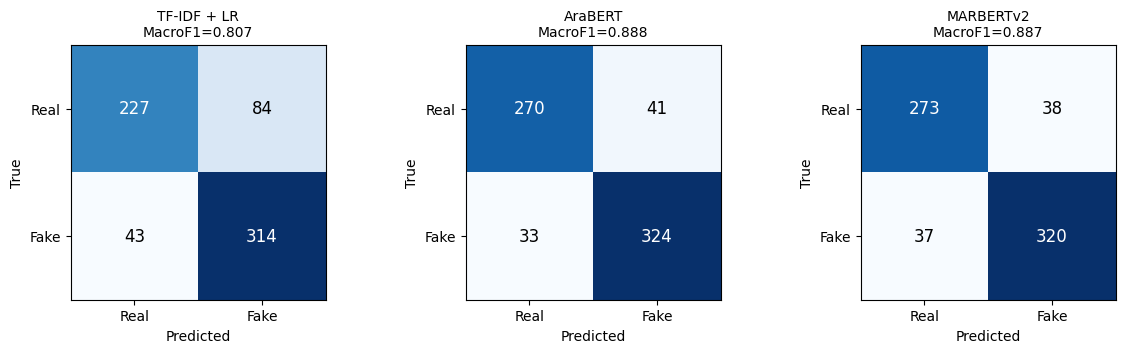

,Model,Macro F1,Accuracy,Notes
0,TF-IDF + LR,0.8066,0.8099,classical baseline
1,AraBERT,0.8885,0.8892,transformer baseline (MSA-pretrained)
2,MARBERTv2,0.8872,0.8877,proposed model


In [ ]:
order = ['TF-IDF + LR', 'AraBERT', 'MARBERTv2']
table = pd.DataFrame([{
    'Model': m,
    'Macro F1': round(RESULTS[m]['macro_f1'], 4),
    'Accuracy': round(RESULTS[m]['accuracy'], 4),
    'Notes': RESULTS[m]['note'],
} for m in order if m in RESULTS])

print('='*64)
print('  MODEL COMPARISON — Saheeh LATE (zero-shot), threshold 0.5')
print('='*64)
print(table.to_string(index=False))

table.to_csv('model_comparison_results.csv', index=False)
print('\n✅ Saved -> model_comparison_results.csv')
plot_confusions()
table

---
## 20. (Secondary) Threshold tuning — applied identically to all three models
**Analysis only — not the headline.** Each model's decision threshold is tuned on the **shared
validation set** and applied to LATE. Because the *same* procedure is applied to *every* model, the
comparison stays fair. This shows how much each model's ranking depends on the decision rule rather
than the encoder.

In [ ]:
def softmax_fake(logits):
    e = np.exp(logits - logits.max(axis=1, keepdims=True))
    return (e / e.sum(axis=1, keepdims=True))[:, 1]

def best_threshold(val_fake, val_y, grid=np.linspace(0.30, 0.70, 41)):
    return max(grid, key=lambda t: f1_score(val_y, (val_fake >= t).astype(int), average='macro'))

if RUN_THRESHOLD_TUNING:
    tuned_rows = []
    # TF-IDF + LR (has predict_proba)
    lr_val_fake  = tfidf_lr.predict_proba(VAL_TEXTS)[:, 1]
    lr_late_fake = tfidf_lr.predict_proba(TEST_TEXTS)[:, 1]
    t_lr = best_threshold(lr_val_fake, VAL_Y)
    p_lr = (lr_late_fake >= t_lr).astype(int)
    tuned_rows.append(['TF-IDF + LR', round(t_lr,3),
                       round(f1_score(TEST_Y, p_lr, average='macro'),4),
                       round(accuracy_score(TEST_Y, p_lr),4)])
    # Transformers
    for name, vlog, llog in [('AraBERT', arabert_val_logits, arabert_late_logits),
                             ('MARBERTv2', marbert_val_logits, marbert_late_logits)]:
        t = best_threshold(softmax_fake(vlog), VAL_Y)
        p = (softmax_fake(llog) >= t).astype(int)
        tuned_rows.append([name, round(t,3),
                           round(f1_score(TEST_Y, p, average='macro'),4),
                           round(accuracy_score(TEST_Y, p),4)])
    tuned = pd.DataFrame(tuned_rows, columns=['Model','Tuned thr','Macro F1 (tuned)','Accuracy (tuned)'])
    print('=== Threshold tuned on shared val, applied to LATE (secondary analysis) ===')
    print(tuned.to_string(index=False))
    tuned.to_csv('model_comparison_tuned.csv', index=False)
else:
    print('Threshold tuning skipped (RUN_THRESHOLD_TUNING=False).')

=== Threshold tuned on shared val, applied to LATE (secondary analysis) ===
      Model  Tuned thr  Macro F1 (tuned)  Accuracy (tuned)
TF-IDF + LR       0.50            0.8066            0.8099
    AraBERT       0.30            0.8913            0.8922
  MARBERTv2       0.38            0.8871            0.8877


In [ ]:
# Final consolidated artifact for the write-up
print('Saved files:')
for f in ['model_comparison_results.csv', 'model_comparison_tuned.csv']:
    if os.path.exists(f): print('  -', f)
print('\nHeadline table:')
print(table.to_string(index=False))

Saved files:
  - model_comparison_results.csv
  - model_comparison_tuned.csv

Headline table:
      Model  Macro F1  Accuracy                                 Notes
TF-IDF + LR    0.8066    0.8099                    classical baseline
    AraBERT    0.8885    0.8892 transformer baseline (MSA-pretrained)
  MARBERTv2    0.8872    0.8877                        proposed model
